In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [37]:
words = open("names.txt").read().splitlines()

In [38]:
tokens = ['.'] + sorted(list(set(''.join(words))))
atoi = { a:i for i,a in enumerate(tokens) }
itoa = { i:a for a,i in atoi.items() }

In [39]:
xs = []
ys = []
for word in words[:1]:
    word = list('.' + word + '.')
    bigrams = zip(word, word[1:])
    
    for ch1, ch2 in bigrams:
        print(ch1, ch2, atoi[ch1],atoi[ch2])
        xs.append(atoi[ch1])
        ys.append(atoi[ch2])

. e 0 5
e m 5 13
m m 13 13
m a 13 1
a . 1 0


In [40]:
XS = torch.tensor(xs)
YS = torch.tensor(ys)

In [41]:
xenc = F.one_hot(XS, len(tokens)).float()

In [42]:
yenc = F.one_hot(YS, len(tokens)).float()

In [43]:
generator = torch.Generator().manual_seed(2147483647)

In [44]:
W = torch.randn((27,27), generator=generator)

In [45]:
import matplotlib.pyplot as plt

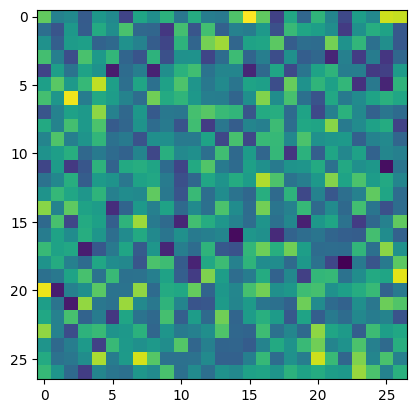

In [46]:
plt.imshow(W)

In [47]:
# forward pass
wx = xenc @ W  # aka logits or log counts
# the follwing is called softmax activation
WX = torch.exp(wx) # use exponentiation to get the actual counts
P = WX / WX.sum(1, keepdim=True) # create a probability distribution for the counts

In [48]:
P[0] # probability distribution w.r.t the input xenc[0]

tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])

In [49]:
nlls = torch.zeros(len(xs))
for i in range(len(xs)):
    print("Input =",itoa[xs[i]], "Label=", itoa[ys[i]], "Prob={0:.3f}".format(P[i, ys[i]].item()))
    nlls[i] = -1 * P[i, ys[i]].log()

print("NLL {0:.3f}".format(nlls.mean().item()))

Input = . Label= e Prob=0.012
Input = e Label= m Prob=0.018
Input = m Label= m Prob=0.027
Input = m Label= a Prob=0.074
Input = a Label= . Prob=0.015
NLL 3.769


In [50]:
len(xs)

5

In [51]:
# A better way than manually iterating over the batch is by doing arange, nll is same as that loss
loss = -1 * P[torch.arange(len(xs)), ys].log().mean().item()
loss

3.7693049907684326

In [52]:
# recap - init weights
generator = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=generator, requires_grad=True)

In [53]:
# forward pass
logits = (xenc @ W)
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -1 * probs[torch.arange(len(xs)), ys].log().mean()
loss

tensor(3.7693, grad_fn=<MulBackward0>)

In [54]:
# backward pass
W.grad = None
loss.backward()
# gradient tells us about the influence of weights on the loss, we can update the weights by reducing the weights as follows
W.data += -1 * W.grad

In [55]:
nlls = torch.zeros(len(xs))
for i in range(len(xs)):
    print("Input =",itoa[xs[i]], "Label=", itoa[ys[i]], "Prob={0:.3f}".format(probs[i, ys[i]].item()))
    nlls[i] = -1 * probs[i, ys[i]].log()

print("Loss {0:.3f}".format(nlls.mean().item()))

Input = . Label= e Prob=0.012
Input = e Label= m Prob=0.018
Input = m Label= m Prob=0.027
Input = m Label= a Prob=0.074
Input = a Label= . Prob=0.015
Loss 3.769


In [56]:
# encoding inputs
xs = []
ys = []
for word in words:
    word = list('.' + word + '.')
    bigrams = zip(word, word[1:])
    
    for ch1, ch2 in bigrams:
        # print(ch1, ch2, atoi[ch1],atoi[ch2])
        xs.append(atoi[ch1])
        ys.append(atoi[ch2])

XS = torch.tensor(xs)
xenc = F.one_hot(XS, len(tokens)).float()


generator = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=generator, requires_grad=True)
loss = None

In [58]:
# Training or adjust the weights to match with actual probability metrics calculated in Makemore 1
for i in range(1000):
    # forward pass
    logits = (xenc @ W)
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -1 * probs[torch.arange(len(xs)), ys].log().mean() + 0.001 * (W**2).mean()
    loss
    # backward pass
    W.grad = None
    loss.backward()
    # gradient tells us about the influence of weights on the loss, we can update the weights by reducing the weights as follows
    W.data += -10 * W.grad

print("The loss value is ", loss)

The loss value is  tensor(2.4606, grad_fn=<AddBackward0>)


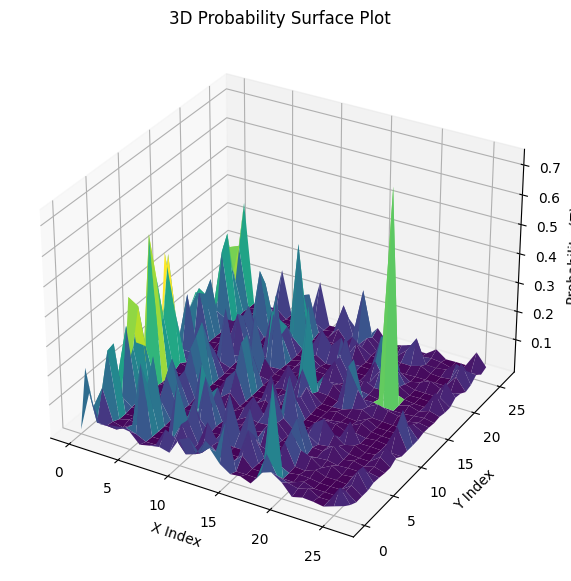

In [59]:
x = y = np.linspace(0,26, 27)
X, Y = np.meshgrid(x,y)
P = W.exp()  #counts
P = P/P.sum(1, keepdim=True) # probabilities
Z = P.detach().numpy()
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel("X Index")
ax.set_ylabel("Y Index")
ax.set_zlabel("Probability (Z)")
ax.set_title("3D Probability Surface Plot")
plt.show()

In [92]:
# sampling
for i in range(10):
    ix = 0
    out = []
    
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        counts = (xenc @ W).exp()
        probs = counts / counts.sum(1, keepdim=True)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=generator).item()
        token = itoa[ix]
        out.append(token)
        if token == '.':
            print(''.join(out))
            break

iluxon.
shamilyn.
y.
miaddjox.
riliayl.
cayx.
emadaellayshe.
jondero.
haliekkana.
efa.


In [89]:
W[torch.arange(27), torch.tensor([0])].log().mean()

tensor(nan, grad_fn=<MeanBackward0>)

In [70]:
# save the weight tensor to disk
torch.save(W, "makemore.pt")

In [57]:
open("makemore.pt")

<_io.TextIOWrapper name='makemore.pt' mode='r' encoding='UTF-8'>